PHOEBE: passband "Bolometric:900-40000" has a newer version available.  Run phoebe.list_passband_online_history("Bolometric:900-40000") to get a list of available changes and phoebe.update_passband("Bolometric:900-40000") or phoebe.update_all_passbands() to update.
PHOEBE: passband "Johnson:V" has a newer version available.  Run phoebe.list_passband_online_history("Johnson:V") to get a list of available changes and phoebe.update_passband("Johnson:V") or phoebe.update_all_passbands() to update.


100%|█████████████████████████████████████████| 253/253 [00:02<00:00, 92.71it/s]
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


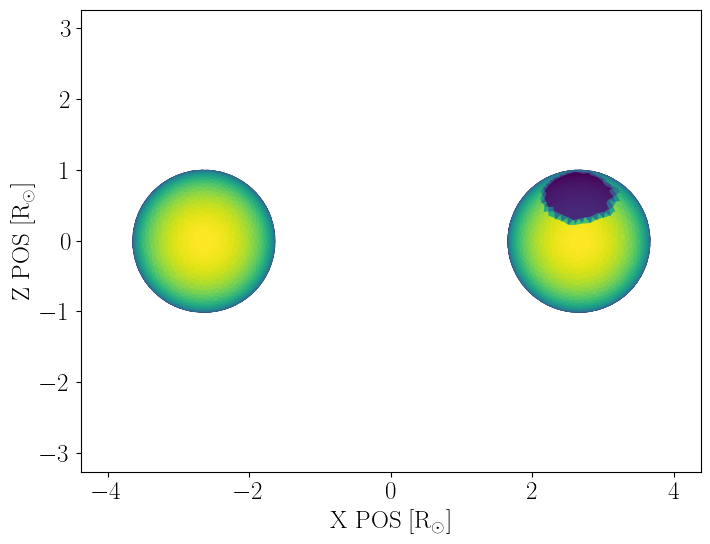

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


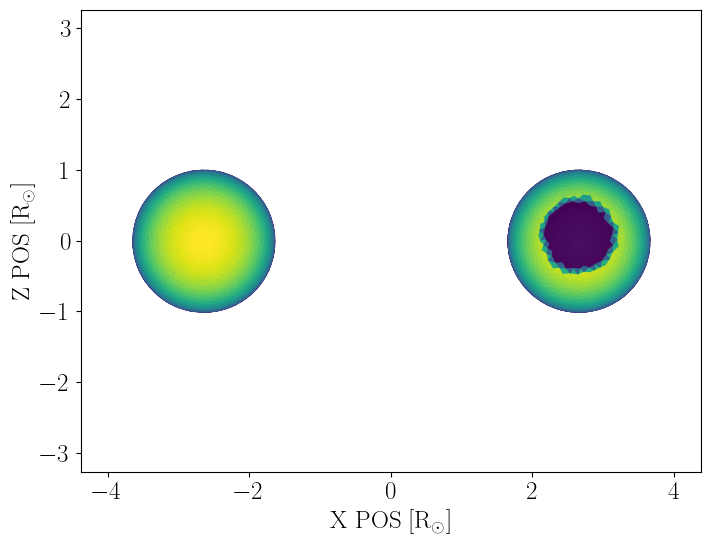

(<autofig.figure.Figure | 1 axes | 2 call(s)>,
 <Figure size 800x600 with 1 Axes>)

In [1]:
import phoebe
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams["font.size"] = 18
matplotlib.rcParams["savefig.dpi"] = 100
from phoebe.features import Spot
from phoebe.parameters import FloatParameter, ParameterSet
from astropy import units as u

b = phoebe.default_binary()
b.add_dataset('lc', compute_phases=phoebe.linspace(0.25,2.25,251))
b.set_value('irrad_method', 'none')
b.set_value_all('distortion_method', 'sphere')
b.set_value_all('ntriangles',3000)

class MigratingSpot(Spot):
    @classmethod
    def create_feature_parameters(self, feature, **kwargs):
        from phoebe.parameters.feature import spot
        from phoebe import u

        params = []
        ps, constraints = spot(feature, **kwargs)
        params = ps.to_list()

        params += [FloatParameter(qualifier='dlongdt',
                                  value=kwargs.get('dlongdt', 0.0),
                                  default_unit=u.deg/u.d,
                                  description='Time derivative of long')]
        params += [FloatParameter(qualifier='dcolatdt',
                                  value=kwargs.get('dcolatdt', 0.0),
                                  default_unit=u.deg/u.d,
                                  description='Time derivative of colat')]

        return ParameterSet(params), constraints
    
    @classmethod
    def parse_bundle(cls, b, feature_ps):
        from phoebe.features import Spot
        spot_kw = Spot.parse_bundle(b, feature_ps)
        addl_kw = cls.parse_from_feature_ps(b, feature_ps,
                                            [{'qualifier': 'dlongdt', 'unit': 'rad/d'},
                                             {'qualifier': 'dcolatdt', 'unit': 'rad/d'}])
        return dict(**spot_kw, **addl_kw)
  
    def instantaneous_position(self, s, time):
        """
        s is the spin vector in roche coordinates
        time is the current time
        """
        t = time - self.kwargs['t0']
        longitude = self.kwargs['longitude'] + (self.kwargs['rot_dlongdt'] + self.kwargs['dlongdt']) * t
        colat = self.kwargs['colat'] + self.kwargs['dcolatdt'] * t
        return longitude, colat

b.add_feature(MigratingSpot, component='primary', relteff=0.75, radius=30, colat=15, long=90, dcolatdt=40, feature='migrating_spot')
b.add_dataset('mesh', compute_phases=np.array([0.75,1.75]), columns='intensities*')
b.run_compute(model='with_migrating_spot')

b.plot(kind='mesh', fc='intensities@lc01', ec='face', time=0.75,show=True,xlabel='X POS', ylabel='Z POS')
b.plot(kind='mesh', fc='intensities@lc01', ec='face', time=1.75,show=True,xlabel='X POS', ylabel='Z POS')

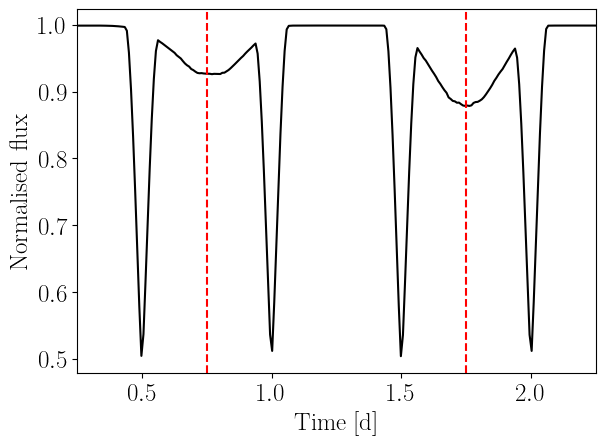

In [2]:
plt.plot(b['times@lc01@model'].value,b['fluxes@lc01@model'].value/2,c='k')
plt.axvline(0.75,ls='--',c='r')
plt.axvline(1.75,ls='--',c='r')
plt.xlabel('Time [d]')
plt.ylabel('Normalised flux')
plt.xlim([0.25,2.25])
plt.tight_layout()
